In [177]:
import numpy as np
import pandas as pd
from catboost import Pool, CatBoostRegressor
import matplotlib.pyplot as plt

In [178]:
def get_horizon():
    return 4

In [179]:
def z_normalization(x: np.array):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    result = (x - mean) / (std + 1e-8)
    return result

def prepare_x(x: np.array, mode: str = "delta"):
    match mode:
        case "delta":
            res = []
            for i in range(1, x.shape[0]):
                delta = x[i] - x[i - 1]
                res.append(delta.tolist())
            return np.array(res)
        case "log_delta":
            res = []
            for i in range(1, x.shape[0]):
                delta = np.log(np.abs(x[i]) + 1e-8) - np.log(np.abs(x[i-1]) + 1e-8)
                res.append(delta.tolist())
            return np.array(res)
        case "normal":
            return x
        case "z_normal":
            return z_normalization(x)
        case _:
            return

def prepare_target(y_raw: np.array, mode: str = "delta"):
    horizon = get_horizon()
    match mode:
        case "delta":
            y = []
            for i in range(y_raw.shape[0] - horizon):
                diff = y_raw[i + horizon] - y_raw[i]
                y.append(diff)
            return np.array(y)
        case "log_delta":
            y = []
            for i in range(y_raw.shape[0] - horizon):
                diff = np.log(y_raw[i + horizon]) - np.log(y_raw[i])
                y.append(diff)
            return np.array(y)
        case "normal":
            return y_raw    
        case "z_normal":
            return z_normalization(y_raw)
        case _:
            return

def create_seq(x: np.array, y: np.array):
    n = 12
    result_x = []
    res_y = []
    for i in range(x.shape[0] - n):
        window = x[i:i+n]
        result_x.append(window)
        res_y.append(y[i+n])
    return np.array(result_x), np.array(res_y)

def prepare_prediction(current_gdp, prediction):
    gdp = current_gdp * np.exp(prediction)
    # gdp = current_gdp * prediction
    return gdp

In [180]:
import os

path = "data/"
directory = os.listdir(path)

In [ ]:
datasets = []

n = get_horizon()

for file in directory:
    if file == "NET_2.csv":
        continue
    if "_3" in file:
        continue
    if file == "FRA_1.csv":
        data4 = pd.read_csv(os.path.join(path, file))
    else:
        datasets.append(pd.read_csv(os.path.join(path, file)))

gdp_plot = []
def prepare_country_data(df):
    global gdp_plot
    gdp = df["gdp"].values
    gdp_plot.extend(gdp[12+4:])
    bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
    for col in bad_cols:
        if col in df.columns:
            df = df.drop([col], axis=1)
    x = df.values[:]
    x = prepare_x(x, mode = "normal")
    return create_seq(x, gdp)


seq_X = []
seqs_y = []



for df in datasets:
    x_s, y_s = prepare_country_data(df)
    x_s = x_s[:-n]
    seq_X.append(x_s)
    seqs_y.append(prepare_target(y_s, mode = "normal"))


X = np.concatenate(seq_X, axis=0)
y = np.concatenate(seqs_y, axis=0)

X_val, y_val_raw = prepare_country_data(data4)
y_val = prepare_target(y_val_raw, mode="normal")

# X_train_flat = z_normalization(X.reshape(X.shape[0], -1))
# X_val_flat = z_normalization(X_val.reshape(X_val.shape[0], -1))
X_train_flat = X.reshape(X.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

TypeError: list.append() takes no keyword arguments

In [ ]:
X_val_flat.shape

(128, 372)

In [ ]:
import scipy.stats as ss
res = ss.pearsonr(X_train_flat, y[:, None], axis=0)
corrs = res.statistic
p_values = res.pvalue

corrs = np.array(corrs)
p_values = np.array(p_values)

In [ ]:
significant_count = np.sum(p_values < 0.01)
print(f"Статистически значимых признаков: {significant_count} из {len(p_values)}")

Статистически значимых признаков: 152 из 372


In [ ]:
import pandas as pd
import numpy as np

correlations = []
for i in range(X_train_flat.shape[1]):
    corr = np.corrcoef(X_train_flat[:, i], y)[0, 1]
    correlations.append(abs(corr))

print(f"Топ корреляций с таргетом: {sorted(correlations)[-5:]}")
print(f"Средняя корреляция: {np.mean(correlations):.4f}")

Топ корреляций с таргетом: [np.float64(0.11816024887859357), np.float64(0.12242099069315908), np.float64(0.12655454899730015), np.float64(0.13112550749402033), np.float64(0.13582482737208812)]
Средняя корреляция: 0.0431


In [ ]:
class OptLoss(object):
    def __init__(self):
        pass
    
    def calc_ders_range(self, approxes, targets, weights):
        assert len(approxes) == len(targets)
        if weights is not None:
            assert len(weights) == len(approxes)
    
        result = []
        for index in range(len(targets)):
            der1 = 2 * (approxes[index] - targets[index])
            penalty = -0.01 / (approxes[index] ** 2 + 1e-4)
            der1 += penalty
            der2 = 1

            if weights is not None:
                der1 *= weights[index]
                der2 *= weights[index]
                
            
            result.append((der1, der2))

        return result

    def is_max_optimal(self):
        return False

In [ ]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=1e-3,
    depth=10,
    early_stopping_rounds=1000,
    verbose=50,
    loss_function='RMSE',
    l2_leaf_reg = 5,
    task_type="GPU",
    bootstrap_type='Bernoulli',
    min_data_in_leaf=2, 
    subsample=0.8,       
)

train_pool = Pool(X_train_flat, y)
validation_pool = Pool(X_val_flat, y_val)

model.fit(train_pool, eval_set=validation_pool)

0:	learn: 1596.5711748	test: 6643.9196262	best: 6643.9196262 (0)	total: 259ms	remaining: 43m 4s
50:	learn: 1582.2362905	test: 6637.5769675	best: 6637.5769675 (50)	total: 12.3s	remaining: 39m 57s
100:	learn: 1569.5479433	test: 6631.0602470	best: 6631.0602470 (100)	total: 24s	remaining: 39m 11s
150:	learn: 1556.5752365	test: 6623.6986646	best: 6623.6986646 (150)	total: 35.7s	remaining: 38m 48s
200:	learn: 1544.4398289	test: 6616.4156460	best: 6616.4156460 (200)	total: 47.4s	remaining: 38m 32s
250:	learn: 1533.1095057	test: 6608.9442425	best: 6608.9442425 (250)	total: 59.2s	remaining: 38m 17s
300:	learn: 1520.5359735	test: 6603.3609624	best: 6603.2140659 (298)	total: 1m 10s	remaining: 38m 4s
350:	learn: 1508.9230191	test: 6596.5139278	best: 6596.5139278 (350)	total: 1m 22s	remaining: 37m 48s
400:	learn: 1497.3123684	test: 6589.7833045	best: 6589.7833045 (400)	total: 1m 34s	remaining: 37m 36s
450:	learn: 1485.6251876	test: 6583.8055864	best: 6583.5999271 (449)	total: 1m 46s	remaining: 37m 

CatBoostRegressor(bootstrap_type='Bernoulli', depth=10, early_stopping_rounds=1000, iterations=10000, l2_leaf_reg=5, learning_rate=0.001, loss_function='RMSE', min_data_in_leaf=2, subsample=0.8, task_type='GPU', verbose=50)

In [ ]:
data_train = pd.read_csv("data/FRA_1.csv")
y_np_t = data_train["gdp"].values
X_np_t = data_train.drop(["date","gdp", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values

# X_z_t = z_normalization(X_np_t)
X_z_t = X_np_t

X_test, real_gdp = create_seq(X_z_t, y_np_t)

prediction = model.predict(X_test.reshape([X_test.shape[0], -1]))


true_pred = []
for i in range(real_gdp.shape[0]):
    curr = real_gdp[i]
    pred = prediction[i]
    true_pred.append(prepare_prediction(curr, pred))

true_pred = np.array(true_pred)


C:\Users\User\AppData\Local\Temp\ipykernel_6408\2605697144.py:61: RuntimeWarning: overflow encountered in exp
  gdp = current_gdp * np.exp(prediction)
C:\Users\User\AppData\Local\Temp\ipykernel_6408\2605697144.py:61: RuntimeWarning: overflow encountered in scalar multiply
  gdp = current_gdp * np.exp(prediction)


In [ ]:
print(prediction.std() > 0.05)
print(prediction.std())

True
362.8873097569058


In [ ]:
print(f"y train std:      {y.std():.6f}")
print(f"y val std:        {y_val.std():.6f}")
print(f"prediction std:   {prediction.std():.6f}")
print(f"prediction mean:  {prediction.mean():.6f}")
print(f"y train mean:     {y.mean():.6f}")
print(f"prediction max:   {prediction.max():.6f}")

y train std:      1596.784562
y val std:        1831.441520
prediction std:   362.887310
prediction mean:  374.582769
y train mean:     71.662209
prediction max:   1252.676540


In [ ]:
x_s, y_s = prepare_country_data(datasets[0])
print(f"create_seq y_s shape: {y_s.shape}")
print(f"x_s shape before [:-1]: {x_s.shape}")
x_s = x_s[:-1]
y_t = prepare_target(y_s)
print(f"x_s after [:-1]: {x_s.shape}")
print(f"prepare_target shape: {y_t.shape}")
print(f"совпадают: {x_s.shape[0] == y_t.shape[0]}")

create_seq y_s shape: (128,)
x_s shape before [:-1]: (128, 12, 31)
x_s after [:-1]: (127, 12, 31)
prepare_target shape: (124,)
совпадают: False


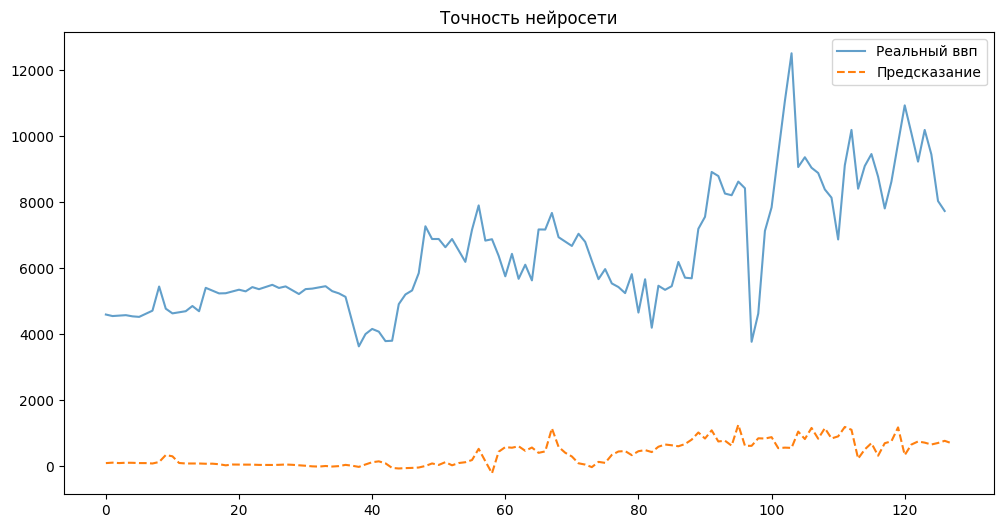

In [ ]:
plt.figure(figsize=(12, 6))
ground_truth = y_np_t[12 + 1:]
plt.plot(ground_truth.tolist(), label='Реальный ввп', alpha=0.7)
plt.plot(prediction, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()

In [ ]:
print(data4["diversification"].diff().describe())

count    139.000000
mean      -0.002014
std        0.270657
min       -0.987000
25%       -0.151000
50%        0.016000
75%        0.140000
max        1.046000
Name: diversification, dtype: float64


In [ ]:
importance = model.get_feature_importance()

temp = data4.copy()

bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
for col in bad_cols:
    if col in temp.columns:
        temp = temp.drop([col], axis=1)
names = temp.columns.tolist()

fancy = []
for n in range(11): 
    years = (11 - n) / 2
    for name in names:
        fancy.append(f"{name} в {years} год")


df = pd.DataFrame(
    {
        "features": fancy,
        "importances": importance,
    }
).sort_values(by = "importances", ascending=False)

ValueError: All arrays must be of the same length

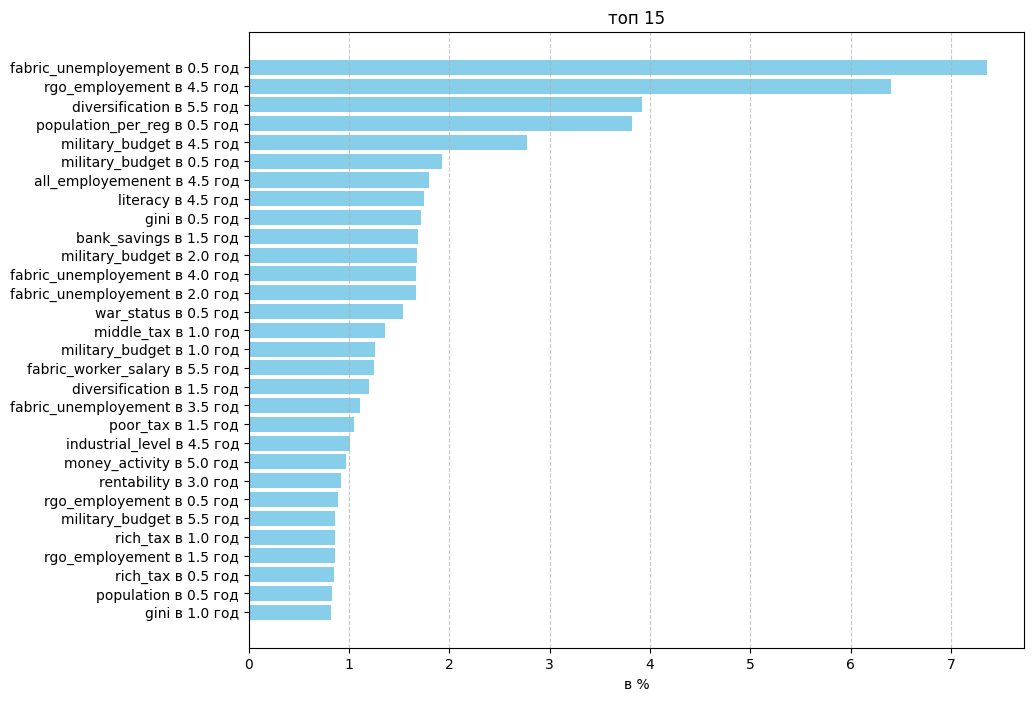

In [ ]:
plt.figure(figsize=(10, 8))

top = df.head(30)

plt.barh(top["features"], top["importances"], color='skyblue')
plt.xlabel('в %')
plt.title('топ 15')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

c:\Users\User\Documents\parser\vic2-save\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


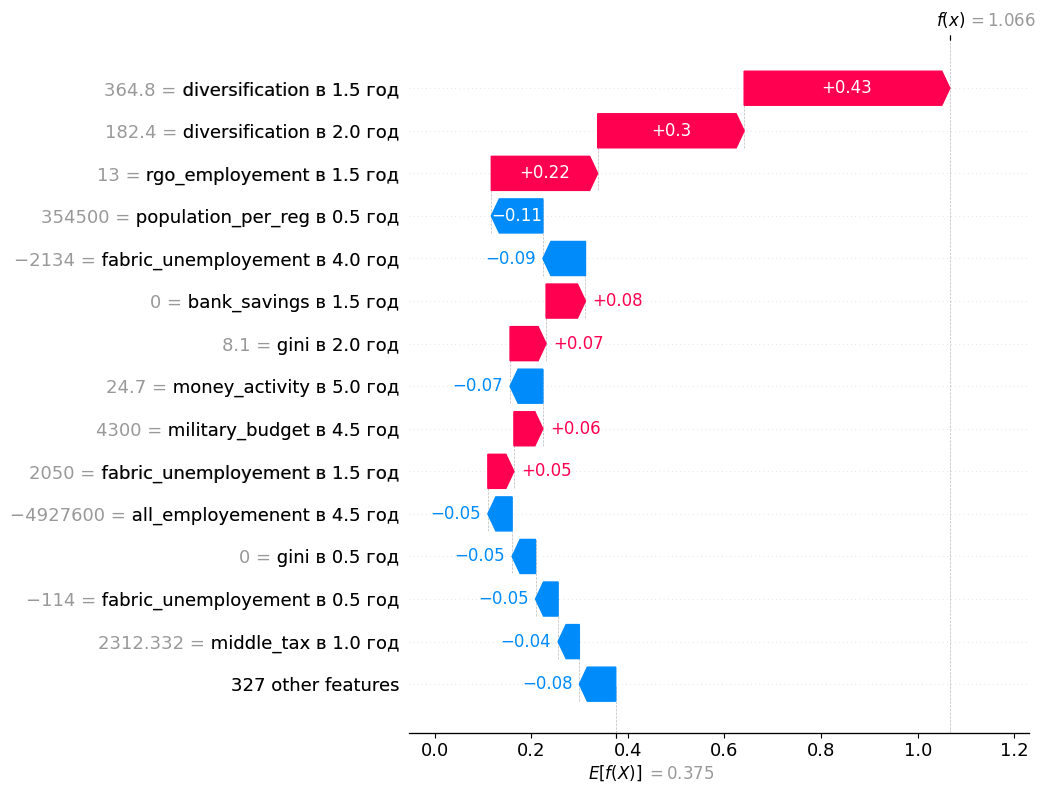

In [ ]:
import shap

fancy_shap = []
for n in range(11): 
    years = (11 - n) / 2
    for name in names:
        fancy_shap.append(f"{name} в {years} год")

explainer = shap.Explainer(model)
shap_values = explainer(X_train_flat)
shap_values.feature_names = fancy_shap

shap.plots.waterfall(shap_values[50] * 100, max_display=15)

In [ ]:
fname = "export_models/model"
model.save_model(fname,
                format="cbm",
                export_parameters=None,
                pool=None)